<a href='https://www.darshan.ac.in/'> <img src='https://www.darshan.ac.in/Content/media/DU_Logo.svg' width="250" height="300"/></a>
<pre>
<center><b><h1>ML</b></center>

<center><b><h1>Lab - 9</b></center>    
<pre>    

# Step 1: Import Libraries
This step imports all necessary libraries for data processing, visualization, and machine learning.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier 
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score ,classification_report , confusion_matrix
import warnings 
warnings.filterwarnings('ignore')

# Step 2: Load the Dataset
Load Given dataset -  heart.csv

In [4]:
df = pd.read_csv('heart.csv')
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


# Step 3: Data Overview
In this step, we examine the dataset structure, summary statistics, and check for missing values.

In [5]:
df.shape

(1025, 14)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [7]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [8]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(723)

# Step 4: Univariate Analysis
Here we visualize the distribution of each feature using histograms.

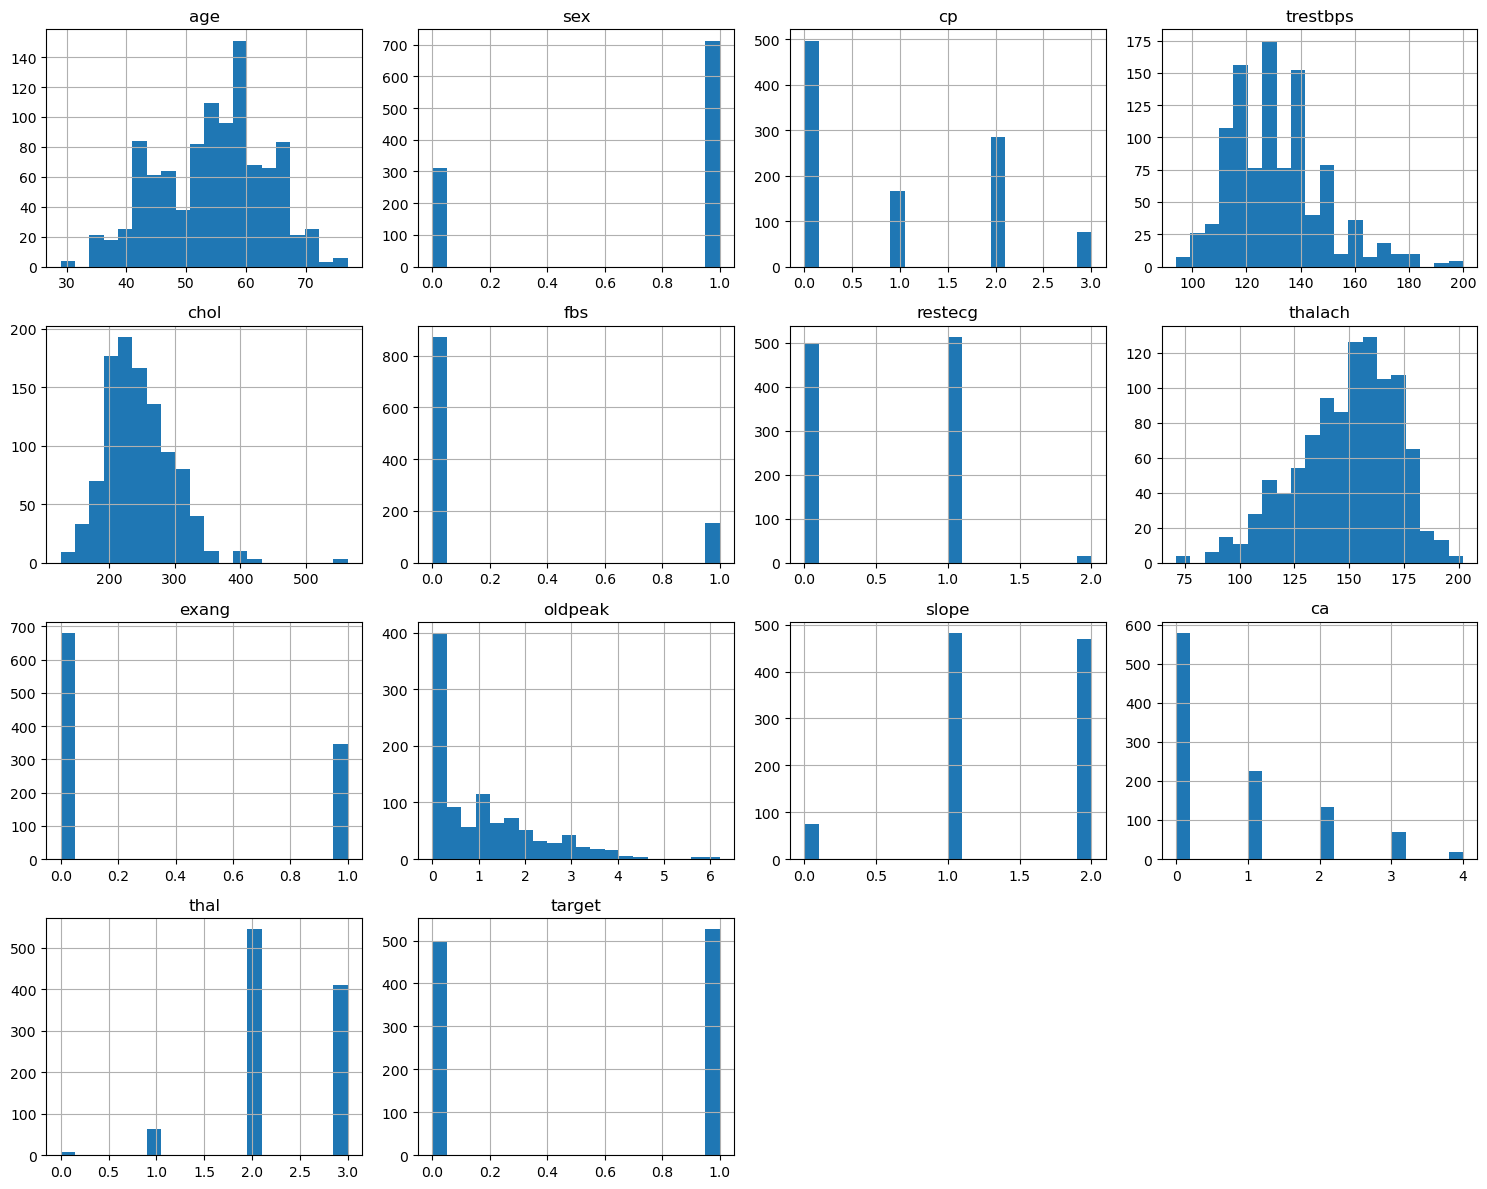

In [10]:
df.hist(figsize=(15,12),bins=20)
plt.tight_layout()
plt.show()

# Step 5: Bivariate Analysis
This step involves exploring the correlations between features using a heatmap.

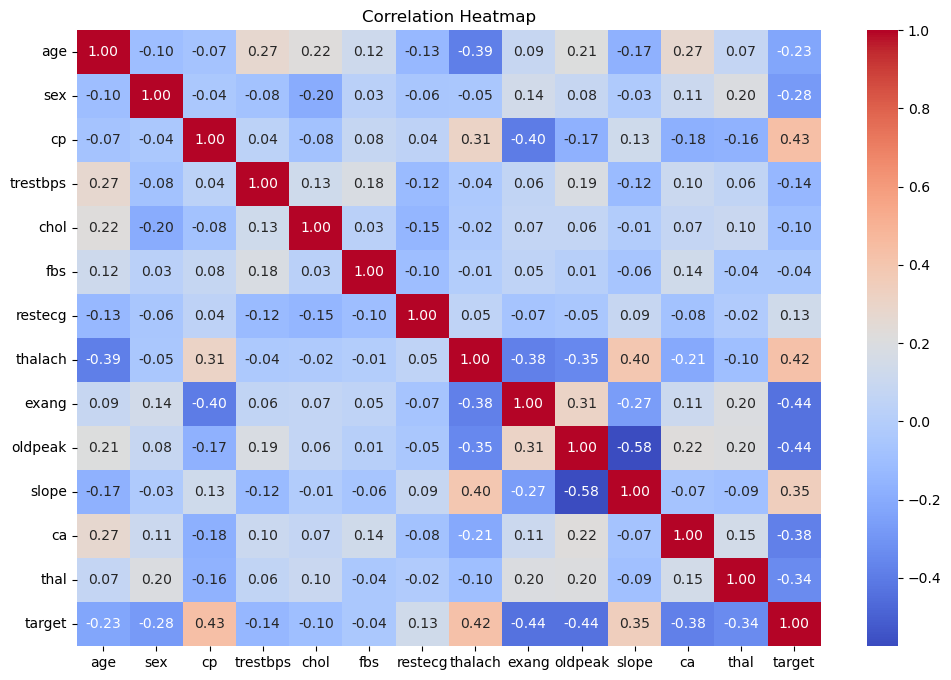

In [11]:
plt.figure(figsize=(12,8))
sns.heatmap(
    df.corr(),
    annot=True,
    cmap= "coolwarm",
    fmt =".2f"
)

plt.title("Correlation Heatmap")
plt.show()

# Step 6: Outlier Detection
We visualize potential outliers using boxplots.

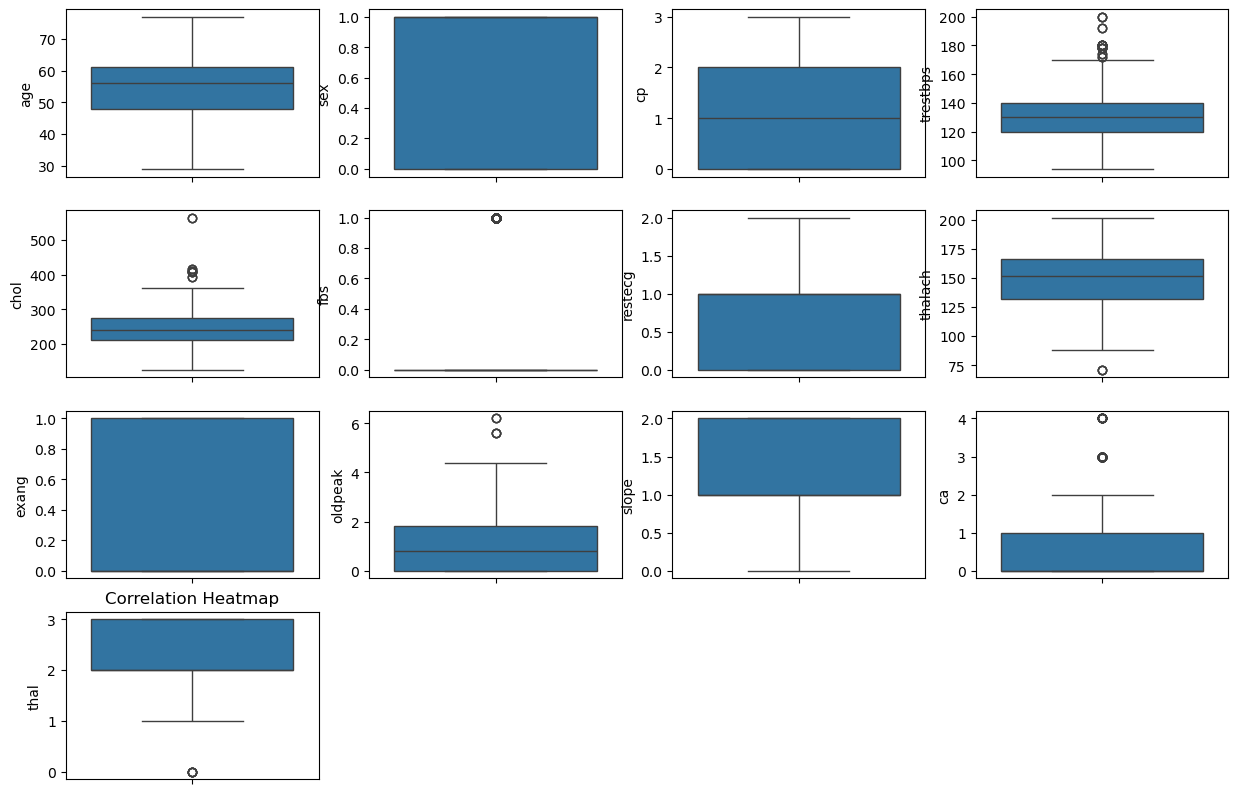

In [12]:
plt.figure(figsize=(15,10))
for i,col in enumerate(df.columns[:-1],1):
    plt.subplot(4,4,i)
    sns.boxplot(y=df[col])
    
plt.title("Correlation Heatmap")
plt.show()

# Step 7: Split Data into Training and Testing Sets
The dataset is split into training and testing sets for model evaluation.

In [13]:
x = df.drop('target',axis = 1)
y = df['target']

In [14]:
X_train ,X_test , y_train ,y_test = train_test_split(x,y,test_size =0.2,random_state = 42, stratify =y)

In [15]:
X_train.shape

(820, 13)

In [16]:
X_test.shape

(205, 13)

# Step 8: Train KNN
train KNN with k three different  <br>
1) 1 <br>
2) root N
3) N

In [17]:
N = len(X_train)
print("Training samples =" ,N)

Training samples = 820


In [18]:
Knn1 = KNeighborsClassifier(n_neighbors = 1)
Knn1.fit(X_train,y_train)
y_pred1=Knn1.predict(X_test)
print("Accuracy =",accuracy_score(y_test ,y_pred1))

Accuracy = 0.9853658536585366


In [19]:
k_root = int(np.sqrt(N))
print("k =",k_root)
Knn2 = KNeighborsClassifier(n_neighbors = 1)
Knn2.fit(X_train,y_train)
y_pred2 = Knn2.predict(X_test)
print("Accuracy =",accuracy_score(y_test ,y_pred2))

k = 28
Accuracy = 0.9853658536585366


In [20]:
Knn3 = KNeighborsClassifier(n_neighbors = N)
Knn3.fit(X_train,y_train)
y_pred3 = Knn3.predict(X_test)
print("Accuracy =",accuracy_score(y_test ,y_pred3))

Accuracy = 0.5121951219512195


# Now train on Z score of Input

# Display confusion matrix and classification Report

In [21]:
cm = confusion_matrix(y_test,y_pred2)
cm

array([[100,   0],
       [  3, 102]])

<pre>
<center><b><h1>ML</b></center>

<center><b><h1>Lab - 10</b></center>    
<pre>    

In [37]:
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import roc_curve , roc_auc_score

# 8. Train Decision Tree

In [38]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


## Evalute Model

In [39]:
dt.score(X_test,y_test)

0.9853658536585366

In [40]:
dt.score(X_train,y_train)

1.0

## Train KNeighborsClassifier

In [41]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train,y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [42]:
knn.score(X_test,y_test)

0.697560975609756

In [43]:
knn.score(X_train,y_train)

0.9170731707317074

## Train GaussianNB

In [44]:
gnb = GaussianNB()
gnb.fit(X_train,y_train)

,priors,None
,var_smoothing,1e-09


In [45]:
gnb.score(X_train,y_train)

0.8304878048780487

In [46]:
gnb.score(X_test,y_test)

0.8292682926829268

## Decision tree CV

In [48]:
cv_dt = cross_val_score(
    dt,
    x,
    y,
    cv= 10,
    scoring='accuracy'
)
print("CV Score :",cv_dt)
print("Mean Accuracy :",cv_dt.mean())

CV Score : [1.         1.         1.         0.97087379 1.         1.
 1.         1.         1.         1.        ]
Mean Accuracy : 0.9970873786407767


## KNN CV

In [50]:
cv_knn = cross_val_score(
    knn,
    x,
    y,
    cv= 10,
    scoring='accuracy'
)
print("CV Score :",cv_knn)
print("Mean Accuracy :",cv_knn.mean())

CV Score : [0.76699029 0.78640777 0.74757282 0.77669903 0.77669903 0.76470588
 0.70588235 0.76470588 0.78431373 0.7254902 ]
Mean Accuracy : 0.7599466971254522


## GaussianNB CV

In [51]:
cv_gnb = cross_val_score(
    gnb,
    x,
    y,
    cv= 10,
    scoring='accuracy'
)
print("CV Score :",cv_gnb)
print("Mean Accuracy :",cv_gnb.mean())

CV Score : [0.85436893 0.88349515 0.87378641 0.76699029 0.84466019 0.88235294
 0.76470588 0.78431373 0.75490196 0.80392157]
Mean Accuracy : 0.821349704930516


## Bagging Classifier

In [52]:
bag = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=100,
    random_state=42
)
bag.fit(X_train,y_train)

,estimator,DecisionTreeClassifier()
,n_estimators,100
,max_samples,1.0
,max_features,1.0
,bootstrap,True
,bootstrap_features,False
,oob_score,False
,warm_start,False
,n_jobs,None
,random_state,42
,verbose,0


In [53]:
bag.score(X_train,y_train)

1.0

In [54]:
bag.score(X_test,y_test)

1.0

## Train Random Forest 

In [55]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state= 42
)
rf.fit(X_train,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [56]:
rf.score(X_test,y_test)

1.0

In [57]:
rf.score(X_train,y_train)

1.0

In [58]:
ada = AdaBoostClassifier(
    n_estimators=100,
    random_state=42
)
ada.fit(X_train,y_train)

,estimator,None
,n_estimators,100
,learning_rate,1.0
,algorithm,'deprecated'
,random_state,42


In [59]:
ada.score(X_test,y_test)

0.8878048780487805

In [60]:
ada.score(X_train,y_train)

0.8963414634146342